# District crime rate prediction

Predicts assault and property crimes per 1,000 people for each district in Malaysia, with two models:
- year-ahead model: trained on 2022, tested on 2023 and used to predict 2024
- cross-district model: predicts the 2020–2023 average rate of districts it was not trained on, from their 2022 characteristics

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# loads the eight raw datasets
crime_raw = pd.read_csv('data/crime_district.csv')
amenities_raw = pd.read_csv('data/hh_access_amenities.csv')
income_raw = pd.read_csv('data/hh_income_district.csv')
inequality_raw = pd.read_csv('data/hh_inequality_district.csv')
poverty_raw = pd.read_csv('data/hh_poverty_district.csv')
population_raw = pd.read_csv('data/population_district.csv')
schools_raw = pd.read_csv('data/schools_district.csv')
enrolment_raw = pd.read_csv('data/enrolment_school_district.csv')

raw_df = {
    'income': income_raw, 'poverty': poverty_raw, 'inequality': inequality_raw,
    'amenities': amenities_raw, 'population': population_raw, 'crime': crime_raw,
    'schools': schools_raw, 'enrolment': enrolment_raw,
}

## Data checks

In [3]:
# size, date range, missing values and duplicate rows of each raw table
pd.DataFrame({name: {'rows': len(table), 'first_date': table['date'].min(), 'last_date': table['date'].max(),
                     'missing': table.isna().sum().sum(), 'duplicates': table.duplicated().sum()}
              for name, table in raw_df.items()}).T

,rows,first_date,last_date,missing,duplicates
income,480,2019-01-01,2024-01-01,0,0
poverty,480,2019-01-01,2024-01-01,0,0
inequality,480,2019-01-01,2024-01-01,0,0
amenities,688,2016-01-01,2024-01-01,75,0
population,383040,2020-01-01,2025-01-01,0,0
crime,19152,2016-01-01,2023-01-01,0,0
schools,3977,2017-01-01,2025-06-30,0,0
enrolment,12756,2017-01-01,2025-06-30,0,0


In [4]:
# rows that are totals of other rows: district 'All' or 'All Districts', or state 'Malaysia'
pd.DataFrame({name: {'All': (table['district'] == 'All').sum(),
                     'All Districts': (table['district'] == 'All Districts').sum(),
                     'Malaysia': (table['state'] == 'Malaysia').sum()}
              for name, table in raw_df.items()}).T

,All,All Districts,Malaysia
income,0,0,0
poverty,0,0,0
inequality,0,0,0
amenities,0,48,0
population,0,0,0
crime,1680,0,112
schools,0,408,24
enrolment,0,1323,78


In [5]:
# compares each state's 'All' crime row with the sum of that state's districts, and lists the rows that differ
crime_districts = crime_raw[(crime_raw['district'] != 'All') & (crime_raw['state'] != 'Malaysia')]
district_sums = crime_districts.groupby(['state', 'category', 'type', 'date'])['crimes'].sum()
state_all_rows = crime_raw[(crime_raw['district'] == 'All') & (crime_raw['state'] != 'Malaysia')].set_index(['state', 'category', 'type', 'date'])['crimes']
all_vs_sum = pd.DataFrame({'all_row': state_all_rows, 'sum_of_districts': district_sums})
all_vs_sum[all_vs_sum['all_row'] != all_vs_sum['sum_of_districts']]

all_row  sum_of_districts
state    category type date                                 
Selangor property all  2020-01-01    13033             13353
                       2021-01-01    11102             11471

Crime, schools, enrolment and amenities have summary rows. Every state 'All' crime row equals the sum of its districts except two Selangor property rows (2020 and 2021), where the districts add up to 320 and 369 more crimes than the 'All' row.

The difference comes from Serdang. Its property 'all' value for 2020 and 2021 is higher than the sum of its property types by exactly its `theft_other` count (320 and 369), so theft_other appears to be counted twice. These two values are corrected below.

In [6]:
# compares each 'all' row with the sum of the other crime types
crime_wide = crime_raw.pivot(index=['state', 'district', 'category', 'date'], columns='type', values='crimes')
crime_wide['sum_of_types'] = crime_wide.drop(columns='all').sum(axis=1)
mismatched = crime_wide[crime_wide['all'] != crime_wide['sum_of_types']]
mismatched[['all', 'sum_of_types', 'theft_other']]

type                                      all  sum_of_types  theft_other
state    district category date                                         
Selangor Serdang  property 2020-01-01  1282.0         962.0        320.0
                           2021-01-01  1197.0         828.0        369.0

In [7]:
# subtracts theft_other from the 'all' rows that don't match
for state, district, category, date in mismatched.index:
    rows = (crime_raw['state'] == state) & (crime_raw['district'] == district) & (crime_raw['category'] == category) & (crime_raw['date'] == date)
    theft_other = crime_raw.loc[rows & (crime_raw['type'] == 'theft_other'), 'crimes'].sum()
    crime_raw.loc[rows & (crime_raw['type'] == 'all'), 'crimes'] -= theft_other

Serdang's property 'all' values are now 962 (2020) and 828 (2021).We remove the summary rows (All, All Districts, Malaysia) before the districts are combined.

In [8]:
# removes the summary rows so the same crimes or people are not counted twice when districts are added up
for name in raw_df:
    table = raw_df[name]
    raw_df[name] = table[~table['district'].isin(['All', 'All Districts']) & (table['state'] != 'Malaysia')]

## District names

The datasets use different district systems: crime uses police districts (IPD), enrolment uses education districts (PPD) and the other tables use administrative districts. The maps below rename every district to one common name. Smaller units are merged into the district that covers them in the crime data.

In [9]:
# federal territories have a 'W.P.' prefix in some files
federal_territory_renames = {
    "W.P. Kuala Lumpur": "Kuala Lumpur",
    "W.P. Labuan": "Labuan",
    "W.P. Putrajaya": "Putrajaya"
}

# different spellings of the same district
spelling_renames = {
    "Kulaijaya": "Kulai", "Ledang": "Tangkak", "Bandar Bharu": "Bandar Baharu",
    "Pasir Putih": "Pasir Puteh", "Cameron Highland": "Cameron Highlands",
    "Kuala Lipis": "Lipis", "Larut & Matang": "Larut dan Matang",
    "Larut Dan Matang": "Larut dan Matang", "Larut Matang & Selama": "Larut/Matang/Selama",
    "Manjung (Dinding)": "Manjung", "Jpn Perlis": "Perlis",
    "S.P. Selatan": "Seberang Perai Selatan", "Sp Selatan": "Seberang Perai Selatan",
    "S.P.Tengah": "Seberang Perai Tengah", "Sp Tengah": "Seberang Perai Tengah",
    "S.P.Utara": "Seberang Perai Utara", "Sp Utara": "Seberang Perai Utara",
    "Kota Kinabatangan": "Kinabatangan", "Pensiangan": "Nabawan",
    "Kota Samarahan": "Samarahan", "Lubok antu": "Lubok Antu", "Meradong": "Maradong",
    "Hulu Langat": "Ulu Langat", "Hulu Selangor": "Ulu Selangor", "Sg. Buloh": "Sungai Buloh",
    "Hulu": "Hulu Terengganu"
}

# police districts and towns that are inside a larger administrative district
sub_districts_to_parents = {
    "Johor Bahru Selatan": "Johor Bahru", "Johor Bahru Utara": "Johor Bahru",
    "Iskandar Puteri": "Johor Bahru", "Nusajaya": "Johor Bahru",
    "Seri Alam": "Johor Bahru", "Pasir Gudang": "Johor Bahru",
    "Nilai": "Seremban", "Ipoh": "Kinta", "Batu Gajah": "Kinta",
    "Kinta Selatan": "Kinta", "Kinta Utara": "Kinta", "Sungai Siput": "Kuala Kangsar",
    "Gerik": "Hulu Perak", "Pengkalan Hulu": "Hulu Perak", "Tapah": "Batang Padang",
    "Tanjong Malim": "Muallim", "Taiping": "Larut dan Matang",
    "Arau": "Perlis", "Kangar": "Perlis", "Padang Besar": "Perlis",
    "Ampang Jaya": "Ulu Langat", "Kajang": "Ulu Langat", "Klang Selatan": "Klang",
    "Klang Utara": "Klang", "Petaling Jaya": "Petaling", "Subang Jaya": "Petaling",
    "Shah Alam": "Petaling", "Sungai Buloh": "Petaling", "Petaling Perdana": "Petaling",
    "Petaling Utama": "Petaling", "Brickfields": "Kuala Lumpur",
    "Cheras": "Kuala Lumpur", "Dang Wangi": "Kuala Lumpur",
    "Sentul": "Kuala Lumpur", "Wangsa Maju": "Kuala Lumpur",
    "Serdang": "Petaling"
}

# districts that are reported together as one unit in at least one dataset
districts_to_combined = {
    "Kuala Muda": "Kuala Muda/Yan", "Yan": "Kuala Muda/Yan",
    "Kulim": "Kulim/Bandar Baharu", "Bandar Baharu": "Kulim/Bandar Baharu",
    "Jempol": "Jempol/Jelebu", "Jelebu": "Jempol/Jelebu",
    "Larut dan Matang": "Larut/Matang/Selama", "Selama": "Larut/Matang/Selama",
    "Telupid": "Telupid/Tongod", "Tongod": "Telupid/Tongod",
    "Tatau": "Tatau/Sebauh", "Sebauh": "Tatau/Sebauh",
    "Matu": "Matu/Daro", "Daro": "Matu/Daro", "Matu Daro": "Matu/Daro"
}

# districts with no crime data of their own, merged into the police district that covers them
police_district_merges = {
    "Pokok Sena": "Kota Setar",
    "Kecil Lojing": "Gua Musang",
    "Bagan Datuk": "Hilir Perak",
    "Kuala Nerus": "Kuala Terengganu",
    "Kalabakan": "Tawau",
    "Kuala Penyu": "Beaufort", "Membakut": "Beaufort",
    "Nabawan": "Keningau", "Tambunan": "Keningau",
    "Pitas": "Kota Marudu",
    "Putatan": "Penampang",
    "Telupid/Tongod": "Beluran",
    "Asajaya": "Samarahan",
    "Beluru": "Marudi", "Telang Usan": "Marudi", "Baram": "Marudi",
    "Bukit Mabong": "Kapit",
    "Gedong": "Simunjan",
    "Kabong": "Saratok", "Pusa": "Saratok",
    "Lingga": "Sri Aman", "Pantu": "Sri Aman", "Sebuyau": "Sri Aman",
    "Pakan": "Julau",
    "Selangau": "Mukah",
    "Siburan": "Padawan",
    "Padawan": "Kuching",
    "Subis": "Miri",
    "Tanjung Manis": "Sarikei",
    "Tebedu": "Serian",
}

district_name_map = {**spelling_renames, **sub_districts_to_parents,
                     **districts_to_combined, **police_district_merges, **federal_territory_renames}

In [10]:
# a name can map to a name that is also in the map (Telupid -> Telupid/Tongod -> Beluran),
# so the lookup repeats until the name no longer changes
def resolve_district_name(district_name):
    seen = set()
    while district_name in district_name_map and district_name not in seen:
        seen.add(district_name)
        district_name = district_name_map[district_name]
    return district_name

spelling_only_map = {**spelling_renames, **federal_territory_renames}

# adds two columns: 'unit' (spelling fixed only, used for population weights) and 'district' (final common name)
def standardise_labels(table):
    labelled = table.copy()
    # crime data puts Putrajaya under Kuala Lumpur and Labuan under Sabah
    labelled.loc[labelled['district'].isin(['W.P. Putrajaya', 'Putrajaya']), 'state'] = 'Putrajaya'
    labelled.loc[labelled['district'].isin(['W.P. Labuan', 'Labuan']), 'state'] = 'Labuan'
    labelled['state'] = labelled['state'].replace(federal_territory_renames)
    labelled['unit'] = labelled['district'].map(lambda name: spelling_only_map.get(name, name))
    labelled['district'] = labelled['district'].map(resolve_district_name)
    return labelled

In [11]:
# state and district pairs after renaming, compared with the crime table (empty lists mean the table matches)
labelled_tables = {name: standardise_labels(table) for name, table in raw_df.items()}
crime_pairs = set(zip(labelled_tables['crime']['state'], labelled_tables['crime']['district']))
for name, table in labelled_tables.items():
    pairs = set(zip(table['state'], table['district']))
    print(name, len(pairs), 'districts | not in crime:', sorted(pairs - crime_pairs), '| missing:', sorted(crime_pairs - pairs))

income 131 districts | not in crime: [] | missing: []
poverty 131 districts | not in crime: [] | missing: []
inequality 131 districts | not in crime: [] | missing: []
amenities 131 districts | not in crime: [] | missing: []
population 131 districts | not in crime: [] | missing: []
crime 131 districts | not in crime: [] | missing: []
schools 131 districts | not in crime: [] | missing: []
enrolment 131 districts | not in crime: [] | missing: []


## Combining districts

When several units become one district:
- counts (population, schools, students, crimes) are added up
- rates (income, poverty, gini, amenities) are combined with a mean weighted by each unit's population, so a unit with more people counts more. Population data starts in 2020, so the 2016 and 2019 surveys use the 2020 population. If a unit has no population row, a simple mean is used.

In [12]:
# count tables: rows that now share the same district are added together
def combine_counts(table):
    labelled = standardise_labels(table).drop(columns='unit')
    group_columns = [column for column in ['state', 'district', 'date', 'category', 'type', 'stage', 'sex', 'age', 'ethnicity']
                     if column in labelled.columns]
    return labelled.groupby(group_columns).sum().reset_index()

clean_tables = {name: combine_counts(raw_df[name]) for name in ['population', 'schools', 'enrolment', 'crime']}

In [13]:
# total population of each original unit per year, used as weights for the rate tables
population_rows = standardise_labels(raw_df['population'])
population_rows = population_rows[(population_rows['sex'] == 'both') & (population_rows['age'] == 'overall') & (population_rows['ethnicity'] == 'overall')]
population_rows['weight_year'] = population_rows['date'].str[:4].astype(int)
unit_weights = population_rows.groupby(['state', 'unit', 'weight_year'])['population'].sum().rename('unit_population').reset_index()

In [14]:
# rate tables: population-weighted mean of the units in each district (missing values are skipped)
def combine_rates(table, rate_columns):
    labelled = standardise_labels(table)
    labelled['weight_year'] = labelled['date'].str[:4].astype(int).clip(2020, 2025)
    labelled = labelled.merge(unit_weights, on=['state', 'unit', 'weight_year'], how='left')
    merged_rows = []
    for (state, district, date), group in labelled.groupby(['state', 'district', 'date']):
        merged_row = {'state': state, 'district': district, 'date': date}
        for column in rate_columns:
            values = group[column].dropna()
            weights = group.loc[values.index, 'unit_population']
            if len(values) == 0:
                merged_row[column] = np.nan
            elif len(values) == 1:
                merged_row[column] = values.iloc[0]
            elif weights.isna().any():
                merged_row[column] = values.mean()
            else:
                merged_row[column] = np.average(values, weights=weights)
        merged_rows.append(merged_row)
    return pd.DataFrame(merged_rows)

rate_columns_by_table = {
    'income': ['income_mean', 'income_median'],
    'poverty': ['poverty_absolute', 'poverty_relative'],
    'inequality': ['gini'],
    'amenities': ['piped_water', 'sanitation', 'electricity'],
}
for name, rate_columns in rate_columns_by_table.items():
    clean_tables[name] = combine_rates(raw_df[name], rate_columns)

## Join by district and year

Each table is reduced to one row per state, district and year:
- population: total row only (both sexes, all ages, all ethnicities)
- crime: the 'all' type of each category, as `crimes_assault` and `crimes_property`
- schools and students: one column per stage (students use both sexes)

In [15]:
join_keys = ['state', 'district', 'year']

# turns the date into a year
def prepare_for_join(table):
    prepared = table.copy()
    prepared['year'] = prepared['date'].str[:4].astype(int)
    return prepared.drop(columns='date')

population = prepare_for_join(clean_tables['population'])
population = population[(population['sex'] == 'both') & (population['age'] == 'overall') & (population['ethnicity'] == 'overall')][join_keys + ['population']]

crime = prepare_for_join(clean_tables['crime'])
crime = crime[crime['type'] == 'all'].pivot(index=join_keys, columns='category', values='crimes').add_prefix('crimes_').reset_index()

schools = prepare_for_join(clean_tables['schools'])
schools = schools.pivot_table(index=join_keys, columns='stage', values='schools', aggfunc='sum').add_prefix('schools_').reset_index()

enrolment = prepare_for_join(clean_tables['enrolment'])
enrolment = enrolment[enrolment['sex'] == 'both'].pivot(index=join_keys, columns='stage', values='students').add_prefix('students_').reset_index()

rate_tables = [prepare_for_join(clean_tables[name]) for name in ['income', 'poverty', 'inequality', 'amenities']]

In [16]:
# outer join keeps every district-year that appears in any table
df_district = population
for table in [crime, schools, enrolment] + rate_tables:
    df_district = df_district.merge(table, on=join_keys, how='outer')
df_district = df_district.sort_values(join_keys).reset_index(drop=True)

# one row per state, district and year
assert not df_district.duplicated(join_keys).any()
df_district

,state,district,year,population,crimes_assault,crimes_property,schools_primary,schools_secondary,schools_tertiary,students_post_secondary,students_primary,students_secondary,income_mean,income_median,poverty_absolute,poverty_relative,gini,piped_water,sanitation,electricity
0,Johor,Batu Pahat,2016,NaN,160.0,621.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,99.9,100.0,100.0
1,Johor,Batu Pahat,2017,NaN,123.0,558.0,144.0,32.0,1.0,NaN,37916.0,32997.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Johor,Batu Pahat,2018,NaN,104.0,584.0,144.0,32.0,1.0,2104.0,37173.0,29601.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Johor,Batu Pahat,2019,NaN,139.0,524.0,144.0,32.0,1.0,1911.0,36797.0,28659.0,7392.0,6504.0,2.9,9.0,0.295,100.0,100.0,100.0
4,Johor,Batu Pahat,2020,495.3,127.0,415.0,144.0,32.0,1.0,1056.0,36317.0,28329.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1305,Terengganu,Setiu,2021,60.5,5.0,38.0,43.0,14.0,0.0,168.0,7921.0,6281.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1306,Terengganu,Setiu,2022,61.5,11.0,40.0,43.0,14.0,0.0,137.0,7826.0,6596.0,6030.0,5211.0,7.5,6.0,0.275,97.2,100.0,100.0
1307,Terengganu,Setiu,2023,62.9,10.0,30.0,43.0,14.0,NaN,169.0,7802.0,6537.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1308,Terengganu,Setiu,2024,64.3,NaN,NaN,43.0,14.0,NaN,173.0,7685.0,6571.0,6359.0,6125.0,4.7,7.7,0.214,100.0,100.0,100.0


In [17]:
# number of districts with a value in each column, per year
df_district.groupby('year').count().T

year,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
state,131,131,131,131,131,131,131,131,131,131
district,131,131,131,131,131,131,131,131,131,131
population,0,0,0,0,131,131,131,131,131,131
crimes_assault,131,131,131,131,131,131,131,131,0,0
crimes_property,131,131,131,131,131,131,131,131,0,0
schools_primary,0,128,131,131,131,131,131,131,131,131
schools_secondary,0,128,131,131,131,131,131,131,131,131
schools_tertiary,0,131,131,131,131,131,131,0,0,0
students_post_secondary,0,0,131,121,131,131,131,130,130,130
students_primary,0,129,131,131,131,131,131,130,130,130


2022 is the only year where every column has a value for all 131 districts, so the model is trained on 2022. Crime data ends in 2023, and the income, poverty and inequality surveys are only for 2019, 2022 and 2024.

In [18]:
# rates per 1,000 people (population is in thousands) and log of population
df_district['assault_per_1000'] = df_district['crimes_assault'] / df_district['population']
df_district['property_per_1000'] = df_district['crimes_property'] / df_district['population']
# students per 1,000 people includes post-secondary students (see the comparison after the 2023 test)
df_district['students_pc'] = (df_district['students_primary'] + df_district['students_secondary'] + df_district['students_post_secondary']) / df_district['population']
# previous definition (primary and secondary only), kept for that comparison
df_district['students_pc_no_post'] = (df_district['students_primary'] + df_district['students_secondary']) / df_district['population']
df_district['schools_pc'] = (df_district['schools_primary'] + df_district['schools_secondary']) / df_district['population']
df_district['log_pop'] = np.log(df_district['population'])

feature_columns = ['log_pop', 'students_pc', 'schools_pc', 'income_median']
target_columns = ['assault_per_1000', 'property_per_1000']
districts_2022 = df_district[df_district['year'] == 2022].copy()

## Exploratory data analysis (2022)

In [19]:
districts_2022[feature_columns + target_columns].describe()

,log_pop,students_pc,schools_pc,income_median,assault_per_1000,property_per_1000
count,131.000000,131.000000,131.000000,131.000000,131.000000,131.000000
mean,4.986112,168.785480,0.550356,4975.553144,0.240783,0.975468
std,0.996955,39.825465,0.357018,1845.508537,0.124022,0.468893
min,2.302585,65.293266,0.092691,2557.254613,0.047170,0.162602
25%,4.363711,145.557286,0.302092,3763.674238,0.146163,0.628117
50%,4.933754,163.097113,0.481050,4431.297409,0.218069,0.897833
75%,5.524448,187.886795,0.686356,5673.000000,0.311778,1.259554
max,7.742749,364.219178,2.000000,12608.000000,0.665096,2.326278


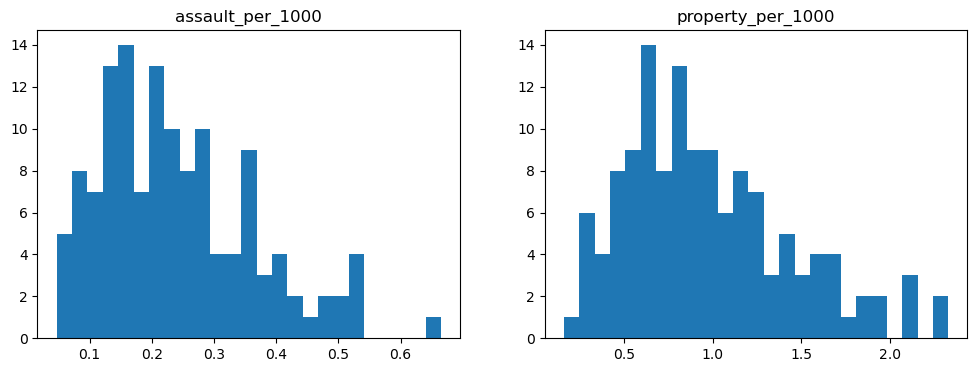

In [20]:
# distribution of the two crime rates across districts
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for axis, target in zip(axes, target_columns):
    axis.hist(districts_2022[target], bins=25)
    axis.set_title(target)
plt.show()

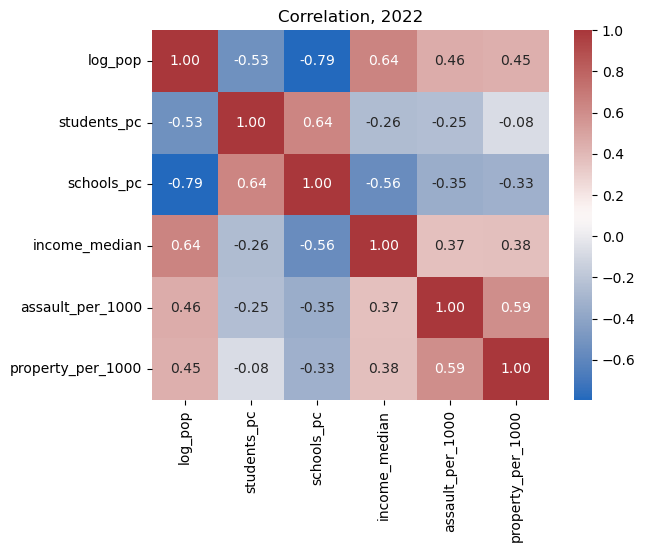

In [21]:
# correlation between the features and the crime rates
sns.heatmap(districts_2022[feature_columns + target_columns].corr(), annot=True, fmt='.2f', cmap='vlag')
plt.title('Correlation, 2022')
plt.show()

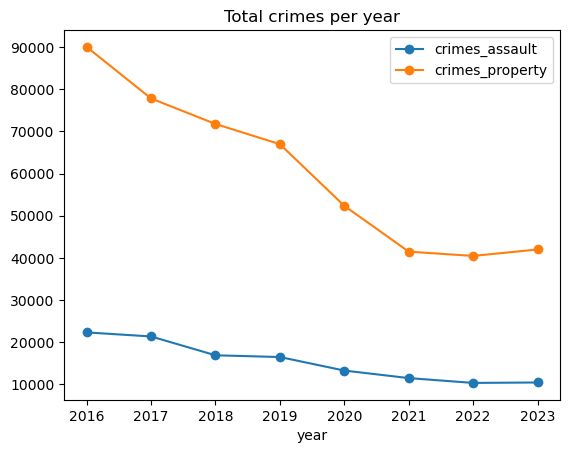

In [22]:
# total crimes in Malaysia per year
df_district.groupby('year')[['crimes_assault', 'crimes_property']].sum().loc[2016:2023].plot(marker='o')
plt.title('Total crimes per year')
plt.show()

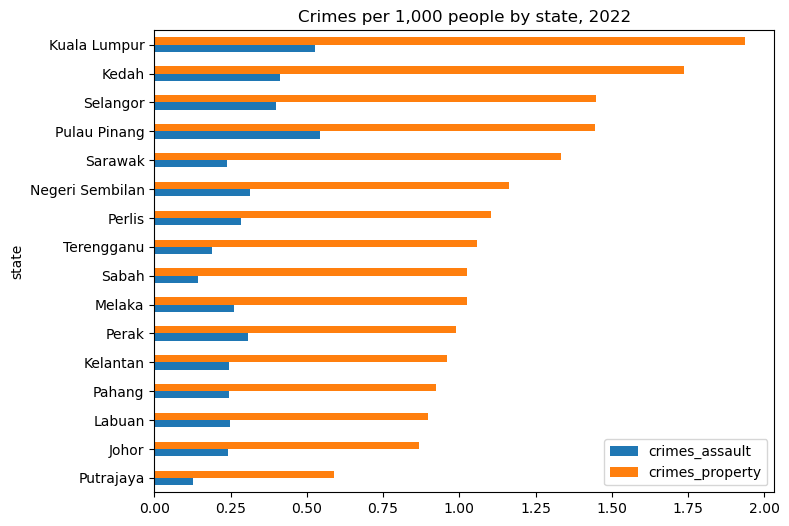

In [23]:
# crimes per 1,000 people in each state, 2022
state_totals = districts_2022.groupby('state')[['crimes_assault', 'crimes_property', 'population']].sum()
state_rates = state_totals[['crimes_assault', 'crimes_property']].div(state_totals['population'], axis=0)
state_rates.sort_values('crimes_property').plot.barh(figsize=(8, 6))
plt.title('Crimes per 1,000 people by state, 2022')
plt.show()

- Both crime rates are right-skewed. Three quarters of the districts are below 0.31 assaults and 1.26 property crimes per 1,000 people, and the highest are 0.67 and 2.33.
- Larger and higher-income districts have higher crime rates (correlation of 0.45 to 0.46 with log population and 0.37 to 0.38 with median income). Districts with more schools per person have lower rates (-0.35 and -0.33).
- The features are also correlated with each other, for example log population and schools per person (-0.79).
- Total crimes fell every year from 2016 to 2022 (assault from 22,327 to 10,348, property from 90,028 to 40,465) and rose slightly in 2023.
- Kuala Lumpur, Kedah, Selangor and Pulau Pinang have the highest rates in 2022. Putrajaya has the lowest for both crime types.

## K-Means clustering (2022)

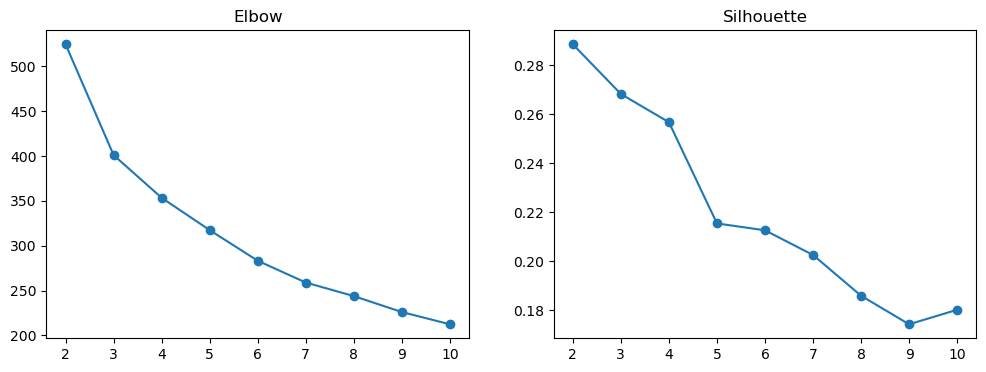

,k,inertia,silhouette
0,2,524.548504,0.288636
1,3,401.023352,0.268323
2,4,353.440138,0.256811
3,5,317.428442,0.215463
4,6,283.283466,0.212653
5,7,259.003899,0.202584
6,8,243.903829,0.185936
7,9,226.115983,0.174275
8,10,212.470990,0.180195


In [24]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

cluster_features = ['log_pop', 'assault_per_1000', 'property_per_1000', 'students_pc', 'schools_pc', 'income_median']
# k-means uses distances, so the features are scaled to the same range
scaled_cluster_features = StandardScaler().fit_transform(districts_2022[cluster_features])

# inertia (elbow) and silhouette score for k = 2 to 10
k_values = range(2, 11)
inertias = []
silhouette_scores = []
for k in k_values:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=0).fit(scaled_cluster_features)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(scaled_cluster_features, kmeans.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(k_values, inertias, marker='o')
axes[0].set_title('Elbow')
axes[1].plot(k_values, silhouette_scores, marker='o')
axes[1].set_title('Silhouette')
plt.show()

pd.DataFrame({'k': k_values, 'inertia': inertias, 'silhouette': silhouette_scores})

Initial k-means with k=4, with these feats = ['log_pop', 'assault_per_1000', 'property_per_1000', 'students_pc', 'schools_pc', 'income_median',
         'poverty_relative', 'gini', 'piped_water', 'electricity'] results in low sillouhette values even as, and the feature distribution graph shows a lot of outliers for piped water and electricity

![iter_1_cluster](./img/cluster_1.png)

![iter_1_elbow](./img/elbow_1.png)

![iter_1_box](img/box_plots_1.png)

in the next iteration we would use ['log_pop', 'assault_per_1000', 'property_per_1000', 'students_pc', 'schools_pc', 'income_median']to see if we can get better sillouhettes

the second iteration shows that we managed to get a lower inertia 401.309793, higher sillhouette 0.269467, at k=3. we will use this as our training baseline for logistic regression. We will train the data on 2022 and test on other years

In [25]:
kmeans_final = KMeans(n_clusters=3, n_init=10, random_state=0).fit(scaled_cluster_features)
districts_2022['cluster'] = kmeans_final.labels_
districts_2022['cluster'].value_counts().sort_index()

cluster
0    71
1    33
2    27
Name: count, dtype: int64

In [26]:
# mean of each feature per cluster
districts_2022.groupby('cluster')[cluster_features].mean()

,log_pop,assault_per_1000,property_per_1000,students_pc,schools_pc,income_median
cluster,,,,,,
0,5.031820,0.219291,0.879154,158.844613,0.446087,4699.999947
1,3.925623,0.152353,0.726173,208.263070,1.033742,3724.608400
2,6.162069,0.405381,1.533429,146.675888,0.233739,7229.088459


In [27]:
# number of districts from each state in each cluster
pd.crosstab(districts_2022['state'], districts_2022['cluster'])

cluster,0,1,2
state,,,
Johor,9,0,1
Kedah,4,0,5
Kelantan,10,0,0
Kuala Lumpur,0,0,1
Labuan,1,0,0
Melaka,2,0,1
Negeri Sembilan,3,2,1
Pahang,10,0,1
Perak,8,2,1


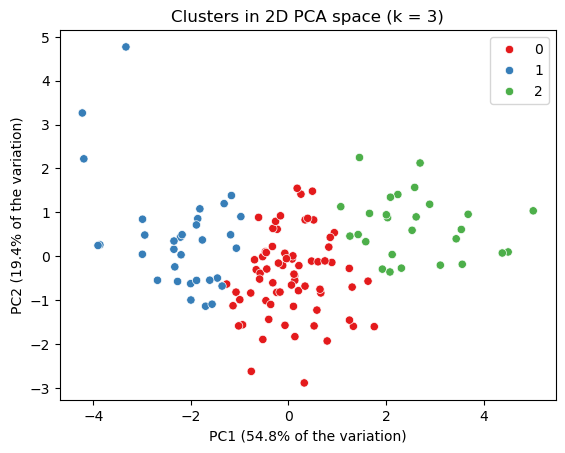

In [28]:
# PCA combines the six scaled clustering features into two axes so the clusters can be drawn in 2D.
# it is only used for this plot, not for the clustering or the models
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_coordinates = pca.fit_transform(scaled_cluster_features)
sns.scatterplot(x=pca_coordinates[:, 0], y=pca_coordinates[:, 1], hue=kmeans_final.labels_, palette='Set1')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} of the variation)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} of the variation)')
plt.title('Clusters in 2D PCA space (k = 3)')
plt.show()

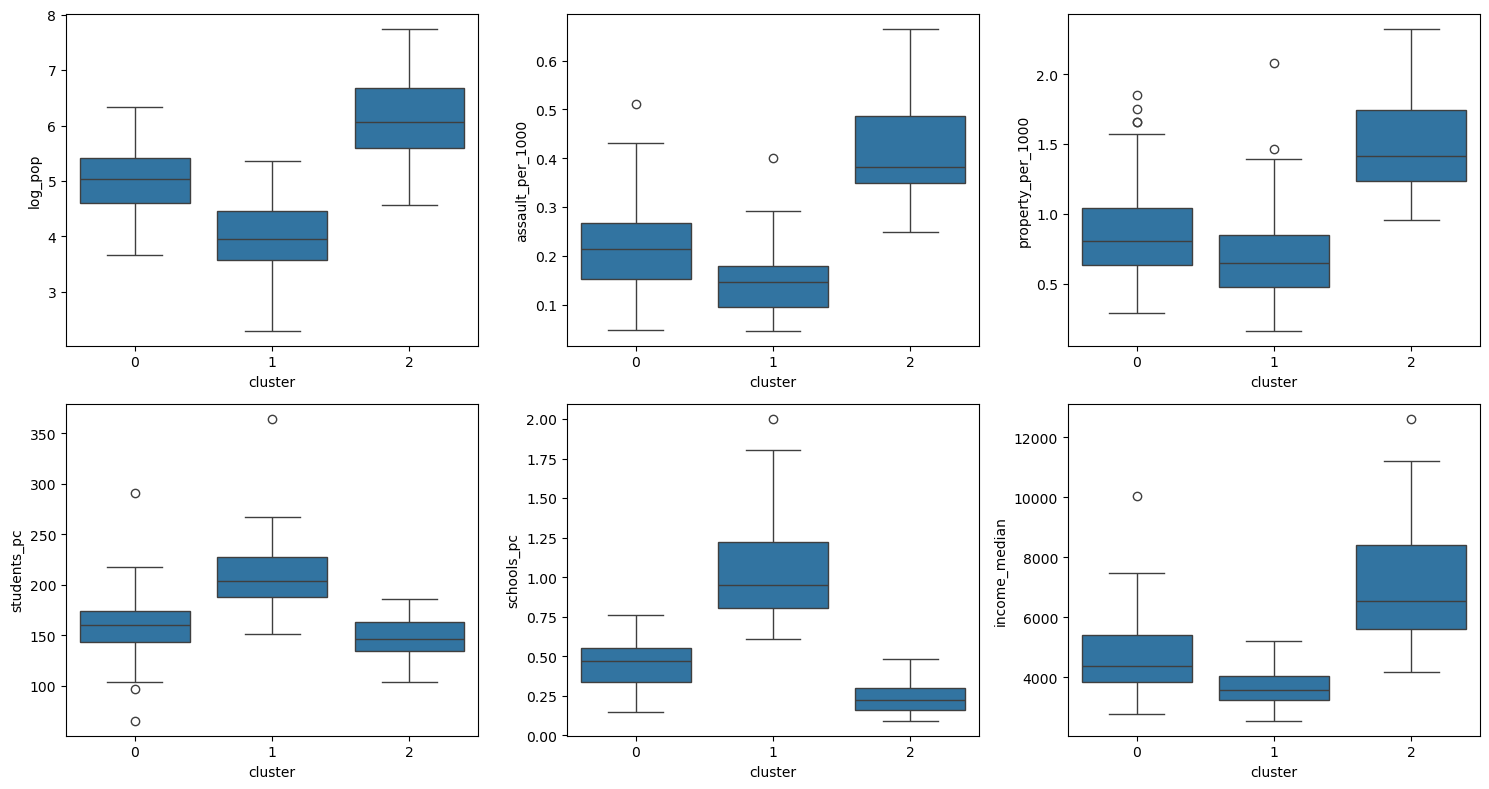

In [29]:
# spread of each feature in each cluster
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for axis, feature in zip(axes.flatten(), cluster_features):
    sns.boxplot(data=districts_2022, x='cluster', y=feature, ax=axis)
plt.tight_layout()
plt.show()

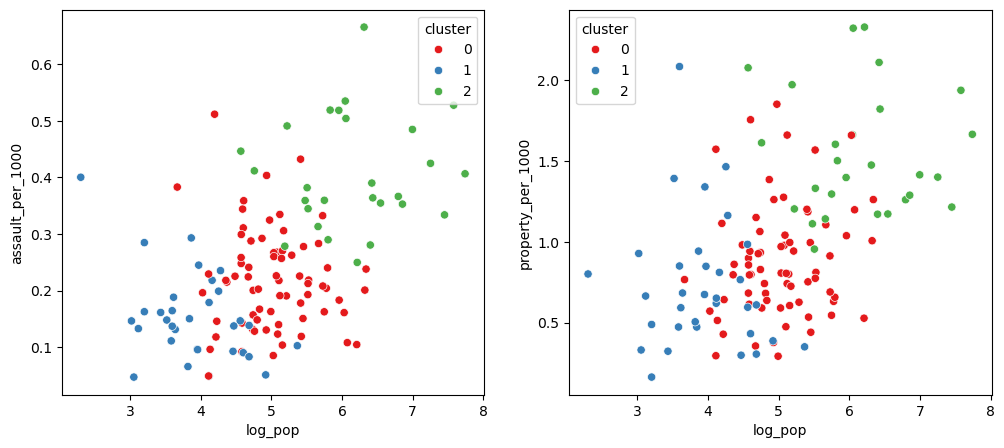

In [30]:
# districts by population and crime rate, coloured by cluster
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for axis, target in zip(axes, target_columns):
    sns.scatterplot(data=districts_2022, x='log_pop', y=target, hue='cluster', palette='Set1', ax=axis)
plt.show()

- Cluster 0 (71 districts): mid-sized districts with crime rates close to the average.
- Cluster 1 (33 districts): small districts with the most schools and students per person, the lowest income and the lowest crime rates. 27 of them are in Sabah and Sarawak.
- Cluster 2 (27 districts): the largest and highest-income districts, with the highest crime rates (0.41 assaults and 1.53 property crimes per 1,000 people on average). 18 of them are in Selangor, Kedah and Pulau Pinang.

In the PCA plot, the clusters sit side by side along PC1, which explains 54.8% of the variation: cluster 1 on the left, cluster 0 in the middle and cluster 2 on the right. Neighbouring clusters touch at their edges, and the silhouette score at k = 3 is 0.27, so the clusters are not clearly separated.

## Preparing the 2023 test set and the 2024 prediction set

2023 has crime data, so it is used to test the model. 2024 has no crime data and is the year the final model predicts.

In [31]:
districts_2023 = df_district[df_district['year'] == 2023].copy()
districts_2024 = df_district[df_district['year'] == 2024].copy()

# missing feature values in each year
pd.DataFrame({'2023': districts_2023[feature_columns].isna().sum(), '2024': districts_2024[feature_columns].isna().sum()})

,2023,2024
log_pop,0,0
students_pc,1,1
schools_pc,0,0
income_median,131,4


In [32]:
# Kampar has no enrolment data after 2022, so its students_pc values are copied from 2022
for column in ['students_pc', 'students_pc_no_post']:
    kampar_2022 = districts_2022.loc[districts_2022['district'] == 'Kampar', column].values
    districts_2023.loc[districts_2023['district'] == 'Kampar', column] = kampar_2022
    districts_2024.loc[districts_2024['district'] == 'Kampar', column] = kampar_2022

There is no income survey in 2023. The 2023 median income is the geometric mean of the 2022 and 2024 survey values, which assumes income grows by the same percentage each year between the two surveys. This uses the 2024 income survey for a 2023 feature; no crime data from after 2023 is used.

In [33]:
income_2022 = districts_2022.set_index('district')['income_median']
income_2024 = districts_2024.set_index('district')['income_median']
districts_2023['income_median'] = np.sqrt(districts_2023['district'].map(income_2022) * districts_2023['district'].map(income_2024))

# districts still missing income
districts_2023.loc[districts_2023['income_median'].isna(), 'district']

297    Kuala Lumpur
307          Labuan
627          Perlis
687       Putrajaya
Name: district, dtype: object

Perlis, Kuala Lumpur, Labuan and Putrajaya have no 2024 income survey, only 2019 and 2022. The yearly growth rate between 2019 and 2022 is continued to 2023 and 2024.

In [34]:
for district in ['Perlis', 'Kuala Lumpur', 'Labuan', 'Putrajaya']:
    income = df_district[df_district['district'] == district].set_index('year')['income_median']
    yearly_growth = (income[2022] / income[2019]) ** (1 / 3)
    districts_2023.loc[districts_2023['district'] == district, 'income_median'] = income[2022] * yearly_growth
    districts_2024.loc[districts_2024['district'] == district, 'income_median'] = income[2022] * yearly_growth ** 2
    print(district, 'yearly growth:', round((yearly_growth - 1) * 100, 2), '%')

# missing feature values after the fills
pd.DataFrame({'2023': districts_2023[feature_columns].isna().sum(), '2024': districts_2024[feature_columns].isna().sum()})

Perlis yearly growth: 0.86 %
Kuala Lumpur yearly growth: -1.01 %
Labuan yearly growth: 0.87 %
Putrajaya yearly growth: 0.24 %


,2023,2024
log_pop,0,0
students_pc,0,0
schools_pc,0,0
income_median,0,0


## Regression models

- Features: log population, students (primary, secondary and post-secondary) and schools per 1,000 people, median income
- Targets: assault and property crimes per 1,000 people, with a separate model for each
- Training set: 2022. Test set: 2023 (the same districts one year later)

Five models are compared: Linear Regression, Decision Tree, Random Forest, KNN and SVM (SVR). Each one is tuned with `GridSearchCV`, which uses 5-fold cross-validation on the 2022 districts: the districts are split into 5 groups, the model is trained on 4 groups and scored (R²) on the 5th, and this is repeated so every group is scored once. The best model for each crime type is then scored once on 2023.

Linear Regression, KNN and SVR are given scaled features, because they are affected by the size of the values (income is in the thousands, the other features are much smaller).

In [35]:
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.model_selection import KFold, GridSearchCV

X_train = districts_2022[feature_columns]
X_test = districts_2023[feature_columns]

# each model with the parameter values GridSearchCV tries
models = {
    'Linear Regression': (make_pipeline(StandardScaler(), LinearRegression()), {}),
    'Decision Tree': (DecisionTreeRegressor(random_state=0), {'max_depth': [2, 3, 5, None], 'min_samples_leaf': [1, 5, 10]}),
    'Random Forest': (RandomForestRegressor(random_state=0), {'max_depth': [3, 5, None], 'min_samples_leaf': [1, 5, 10]}),
    'KNN': (make_pipeline(StandardScaler(), KNeighborsRegressor()), {'kneighborsregressor__n_neighbors': [3, 5, 10, 15, 20]}),
    'SVR': (make_pipeline(StandardScaler(), SVR()), {'svr__C': [0.1, 1, 10], 'svr__epsilon': [0.01, 0.05, 0.1]}),
}
folds = KFold(n_splits=5, shuffle=True, random_state=0)

# tunes every model with GridSearchCV for each crime type and keeps the one with the highest cross-validated R2
def tune_models(models, X, targets_table):
    cv_results = []
    best_models = {}
    for target in target_columns:
        best_score = None
        for model_name, (model, parameters) in models.items():
            search = GridSearchCV(model, parameters, cv=folds, scoring='r2').fit(X, targets_table[target])
            cv_results.append({'target': target, 'model': model_name, 'cv_r2': search.best_score_, 'best_parameters': search.best_params_})
            if best_score is None or search.best_score_ > best_score:
                best_score = search.best_score_
                best_models[target] = (model_name, search.best_estimator_)
    return pd.DataFrame(cv_results), best_models

cv_results, best_models = tune_models(models, X_train, districts_2022)
cv_results

,target,model,cv_r2,best_parameters
0,assault_per_1000,Linear Regression,0.097720,{}
1,assault_per_1000,Decision Tree,-0.167306,"{'max_depth': 3, 'min_samples_leaf': 10}"
2,assault_per_1000,Random Forest,0.041741,"{'max_depth': 3, 'min_samples_leaf': 10}"
3,assault_per_1000,KNN,0.135773,{'kneighborsregressor__n_neighbors': 20}
4,assault_per_1000,SVR,0.187716,"{'svr__C': 0.1, 'svr__epsilon': 0.05}"
5,property_per_1000,Linear Regression,0.192708,{}
6,property_per_1000,Decision Tree,0.191058,"{'max_depth': 2, 'min_samples_leaf': 10}"
7,property_per_1000,Random Forest,0.229307,"{'max_depth': 3, 'min_samples_leaf': 5}"
8,property_per_1000,KNN,0.182902,{'kneighborsregressor__n_neighbors': 20}
9,property_per_1000,SVR,0.210613,"{'svr__C': 1, 'svr__epsilon': 0.1}"


In [36]:
# cross-validated R2 of each tuned model
cv_results.pivot(index='model', columns='target', values='cv_r2')

target,assault_per_1000,property_per_1000
model,,
Decision Tree,-0.167306,0.191058
KNN,0.135773,0.182902
Linear Regression,0.097720,0.192708
Random Forest,0.041741,0.229307
SVR,0.187716,0.210613


- All cross-validated R² values are low: 0.19 or less for assault and 0.23 or less for property. The four features explain a small part of the differences in crime rates between districts.
- The best tuned model is SVR for assault (0.19) and Random Forest for property (0.23). These two are used for the test.
- The Decision Tree has a negative R² for assault, which means it does worse than predicting the average rate for every district.

### Test on 2023

The chosen models are scored on 2023 and compared with a simple baseline that uses each district's 2022 rate as its 2023 prediction. Crime rates change little from one year to the next, so a useful model should do better than this baseline.

In [37]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

def regression_scores(actual, predicted):
    mse = mean_squared_error(actual, predicted)
    return {'R2': r2_score(actual, predicted), 'MAE': mean_absolute_error(actual, predicted), 'MSE': mse, 'RMSE': np.sqrt(mse)}

rates_2022 = districts_2022.set_index('district')[target_columns]
test_results = []
test_predictions = {}
for target in target_columns:
    model_name, model = best_models[target]
    test_predictions[target] = model.predict(X_test)
    test_results.append({'target': target, 'model': model_name, **regression_scores(districts_2023[target], test_predictions[target])})
    last_year = districts_2023['district'].map(rates_2022[target])
    test_results.append({'target': target, 'model': 'baseline (2022 rate)', **regression_scores(districts_2023[target], last_year)})

pd.DataFrame(test_results)

,target,model,R2,MAE,MSE,RMSE
0,assault_per_1000,SVR,0.265942,0.081080,0.012107,0.110030
1,assault_per_1000,baseline (2022 rate),0.475026,0.063922,0.008658,0.093050
2,property_per_1000,Random Forest,0.334032,0.278549,0.130499,0.361246
3,property_per_1000,baseline (2022 rate),0.793904,0.152685,0.040385,0.200961


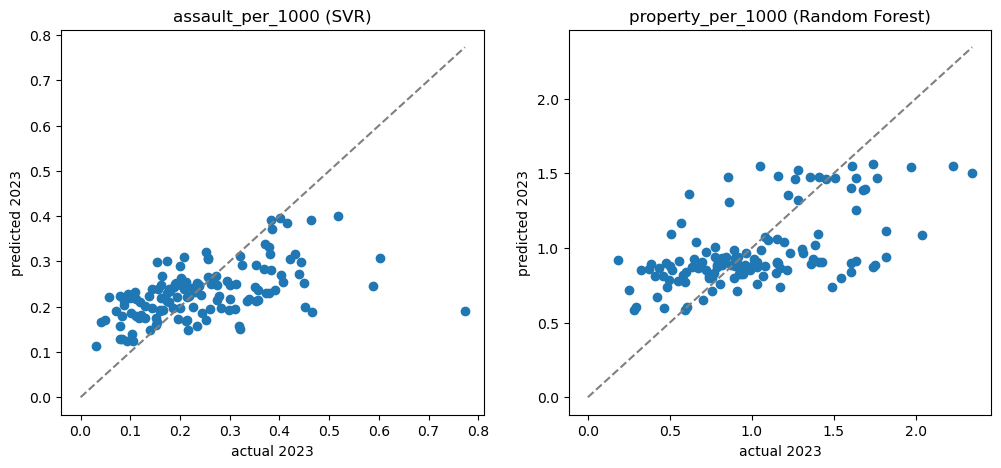

In [38]:
# actual vs predicted 2023 rates; points on the dashed line are exact predictions
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for axis, target in zip(axes, target_columns):
    axis.scatter(districts_2023[target], test_predictions[target])
    limit = districts_2023[target].max()
    axis.plot([0, limit], [0, limit], linestyle='--', color='grey')
    axis.set_title(f'{target} ({best_models[target][0]})')
    axis.set_xlabel('actual 2023')
    axis.set_ylabel('predicted 2023')
plt.show()

- Both models score below the baseline: R² 0.27 vs 0.48 for assault (SVR) and 0.33 vs 0.79 for property (Random Forest).
- A district's 2022 and 2023 rates are strongly related (correlation 0.73 for assault and 0.91 for property), so last year's rate is a strong predictor. It already contains each district's own level of crime, which the four features only partly explain.
- The predictions vary less than the actual rates. Districts with high rates are predicted too low and districts with low rates too high.

### Test: post-secondary students in students_pc

`students_pc` now counts primary, secondary and post-secondary students. The cell below repeats the tuning and the 2023 test with the previous definition (primary and secondary only) so the two can be compared.

In [39]:
# same tuning and 2023 test with the previous students_pc (primary and secondary only)
previous_features = ['log_pop', 'students_pc_no_post', 'schools_pc', 'income_median']
previous_cv_results, previous_best_models = tune_models(models, districts_2022[previous_features], districts_2022)

comparison = []
for label, features, cv_table, best in [('with post-secondary', feature_columns, cv_results, best_models),
                                         ('without post-secondary', previous_features, previous_cv_results, previous_best_models)]:
    for target in target_columns:
        model_name, model = best[target]
        comparison.append({'students_pc': label, 'target': target, 'model': model_name,
                           'cv_r2': cv_table[cv_table['target'] == target]['cv_r2'].max(),
                           'test_r2_2023': r2_score(districts_2023[target], model.predict(districts_2023[features]))})
pd.DataFrame(comparison)

,students_pc,target,model,cv_r2,test_r2_2023
0,with post-secondary,assault_per_1000,SVR,0.187716,0.265942
1,with post-secondary,property_per_1000,Random Forest,0.229307,0.334032
2,without post-secondary,assault_per_1000,SVR,0.190104,0.265982
3,without post-secondary,property_per_1000,Random Forest,0.226879,0.333029


- With post-secondary students, the cross-validated R² is 0.187 for assault (SVR) and 0.229 for property (Random Forest), and the 2023 test R² is 0.266 and 0.334.
- Without them, the cross-validated R² is 0.190 and 0.227, and the 2023 test R² is 0.266 and 0.333.
- The same models are chosen either way, and the scores differ by less than 0.003. Post-secondary students are a small part of all students, so `students_pc` goes up by 1.7% on average (mean 166.0 to 168.8 per 1,000 people in 2022).
- `students_pc` with post-secondary students is used for the rest of the notebook, including the cross-district model.

## Final model and 2024 prediction

The chosen models are trained again on 2022 and 2023 together, then used to predict 2024. There is no 2024 crime data, so these predictions cannot be checked yet.

In [40]:
from sklearn.base import clone

training_2022_2023 = pd.concat([districts_2022, districts_2023])
final_models = {}
for target in target_columns:
    final_models[target] = clone(best_models[target][1]).fit(training_2022_2023[feature_columns], training_2022_2023[target])
    districts_2024['predicted_' + target] = final_models[target].predict(districts_2024[feature_columns])

districts_2024[['state', 'district', 'predicted_assault_per_1000', 'predicted_property_per_1000']]

,state,district,predicted_assault_per_1000,predicted_property_per_1000
8,Johor,Batu Pahat,0.336212,1.211238
18,Johor,Johor Bahru,0.414261,1.523807
28,Johor,Kluang,0.258188,1.088349
38,Johor,Kota Tinggi,0.233336,0.948213
48,Johor,Kulai,0.321249,1.348594
...,...,...,...,...
1268,Terengganu,Hulu Terengganu,0.214569,0.950686
1278,Terengganu,Kemaman,0.244163,1.061301
1288,Terengganu,Kuala Terengganu,0.238189,1.264213
1298,Terengganu,Marang,0.243488,1.035347


## Cross-district model (2020–2023 average)

The year-ahead model predicts the same districts one year later. This model predicts the crime rates of districts it was not trained on, from their 2022 characteristics.

- Target: crimes per 1,000 people averaged over 2020–2023 (total crimes / total population over the four years). Single-year rates change a lot by chance in districts with few crimes, and the average reduces this.
- Features (2022): the year-ahead features (with post-secondary students in `students_pc`), plus mean income, absolute and relative poverty, gini, piped water access, the share of males aged 15–29, the share of people aged 65 and over, the share of males, and the state as 0/1 columns (one-hot encoding). Sanitation and electricity are left out because most districts are at or close to 100%.
- Training and test sets: the districts are split at random into 80% for training (104 districts) and 20% for testing (27 districts), and this is repeated with 10 different splits. With 27 test districts, a single split gives a score that depends a lot on which districts end up in the test set. For each split, the five models are tuned with `GridSearchCV` (5-fold cross-validation) on the training districts, and the best model for each crime type is scored on the test districts.
- Saved models: chosen and trained with `GridSearchCV` on all 131 districts, so the choice does not depend on one split.
- Models: Linear Regression, Decision Tree, Random Forest, KNN and SVR, as in the year-ahead model.

In [41]:
# age and sex shares of each district's 2022 population (the join above keeps only the total population)
population_2022 = prepare_for_join(clean_tables['population'])
population_2022 = population_2022[(population_2022['year'] == 2022) & (population_2022['ethnicity'] == 'overall')]
total_population = population_2022[(population_2022['sex'] == 'both') & (population_2022['age'] == 'overall')].set_index('district')['population']
young_males = population_2022[(population_2022['sex'] == 'male') & population_2022['age'].isin(['15-19', '20-24', '25-29'])].groupby('district')['population'].sum()
aged_65_plus = population_2022[(population_2022['sex'] == 'both') & population_2022['age'].isin(['65-69', '70-74', '75-79', '80-84', '85+'])].groupby('district')['population'].sum()
males = population_2022[(population_2022['sex'] == 'male') & (population_2022['age'] == 'overall')].set_index('district')['population']

In [42]:
# one row per district: 2022 features and the 2020-2023 average crime rates
cross_district = districts_2022.set_index('district')
cross_district['young_male_share'] = young_males / total_population
cross_district['age65_share'] = aged_65_plus / total_population
cross_district['male_share'] = males / total_population

# the target columns keep the same names as in the year-ahead model, but hold the 2020-2023 averages
totals_2020_2023 = df_district[df_district['year'].between(2020, 2023)].groupby('district')[['crimes_assault', 'crimes_property', 'population']].sum()
cross_district['assault_per_1000'] = totals_2020_2023['crimes_assault'] / totals_2020_2023['population']
cross_district['property_per_1000'] = totals_2020_2023['crimes_property'] / totals_2020_2023['population']

cross_district_features = feature_columns + ['income_mean', 'poverty_absolute', 'poverty_relative', 'gini', 'piped_water',
                                             'young_male_share', 'age65_share', 'male_share', 'state']
# missing values in the features and targets
print(cross_district[cross_district_features + target_columns].isna().sum().sum())

0


In [43]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder

# state becomes 0/1 columns and the other features are scaled. handle_unknown='ignore' is needed because a state
# with one district (Perlis, Kuala Lumpur, Labuan, Putrajaya) can be in the test set without being in the training set
state_and_scaling = make_column_transformer((OneHotEncoder(handle_unknown='ignore'), ['state']), remainder=StandardScaler())

cross_district_models = {
    'Linear Regression': (make_pipeline(state_and_scaling, LinearRegression()), {}),
    'Decision Tree': (make_pipeline(state_and_scaling, DecisionTreeRegressor(random_state=0)),
                      {'decisiontreeregressor__max_depth': [2, 3, 5, None], 'decisiontreeregressor__min_samples_leaf': [1, 5, 10]}),
    'Random Forest': (make_pipeline(state_and_scaling, RandomForestRegressor(random_state=0)),
                      {'randomforestregressor__max_depth': [3, 5, None], 'randomforestregressor__min_samples_leaf': [1, 5, 10]}),
    'KNN': (make_pipeline(state_and_scaling, KNeighborsRegressor()), {'kneighborsregressor__n_neighbors': [3, 5, 10, 15, 20]}),
    'SVR': (make_pipeline(state_and_scaling, SVR()), {'svr__C': [0.1, 1, 10], 'svr__epsilon': [0.01, 0.05, 0.1]}),
}

In [44]:
from sklearn.model_selection import train_test_split

# 10 random 80/20 splits of the districts. For each split, the models are tuned on the training districts
# and the chosen model for each crime type is scored on the test districts
repeated_results = []
for split in range(10):
    train_districts, test_districts = train_test_split(cross_district, test_size=0.2, random_state=split)
    split_cv_results, split_best_models = tune_models(cross_district_models, train_districts[cross_district_features], train_districts)
    for target in target_columns:
        model_name, model = split_best_models[target]
        predictions = model.predict(test_districts[cross_district_features])
        repeated_results.append({'split': split, 'target': target, 'model': model_name,
                                 'cv_r2': split_cv_results[split_cv_results['target'] == target]['cv_r2'].max(),
                                 **regression_scores(test_districts[target], predictions)})
repeated_results = pd.DataFrame(repeated_results)
repeated_results

,split,target,model,cv_r2,R2,MAE,MSE,RMSE
0,0,assault_per_1000,SVR,0.395331,0.330504,0.051286,0.004509,0.067149
1,0,property_per_1000,SVR,0.329164,0.204293,0.271022,0.125985,0.354944
2,1,assault_per_1000,SVR,0.450473,0.451462,0.066537,0.006419,0.080120
3,1,property_per_1000,Linear Regression,0.282627,0.377964,0.241452,0.087389,0.295617
4,2,assault_per_1000,SVR,0.503941,0.529525,0.059891,0.005978,0.077318
5,2,property_per_1000,Linear Regression,0.339296,0.437740,0.282489,0.116343,0.341091
6,3,assault_per_1000,KNN,0.464177,0.262938,0.082135,0.012846,0.113340
7,3,property_per_1000,Linear Regression,0.405498,0.231391,0.344090,0.188586,0.434265
8,4,assault_per_1000,SVR,0.565400,0.379528,0.081846,0.011668,0.108018
9,4,property_per_1000,Linear Regression,0.435218,0.258168,0.286824,0.166059,0.407503


In [45]:
# mean, lowest and highest test scores over the 10 splits
repeated_results.groupby('target')[['R2', 'MAE', 'MSE', 'RMSE']].agg(['mean', 'min', 'max'])

R2                           MAE                      \
                       mean       min       max      mean       min       max   
target                                                                          
assault_per_1000   0.370208 -0.457696  0.673179  0.069755  0.051286  0.097255   
property_per_1000  0.311582 -0.169313  0.710429  0.292660  0.212130  0.368657   

                        MSE                          RMSE                      
                       mean       min       max      mean       min       max  
target                                                                         
assault_per_1000   0.008157  0.004509  0.013561  0.088795  0.067149  0.116451  
property_per_1000  0.141856  0.073050  0.226633  0.371355  0.270278  0.476060

In [46]:
# number of splits in which each model was chosen
pd.crosstab(repeated_results['model'], repeated_results['target'])

target,assault_per_1000,property_per_1000
model,,
KNN,1,0
Linear Regression,2,8
SVR,7,2


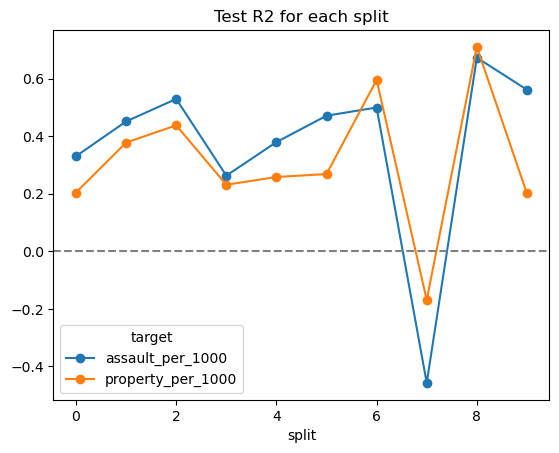

In [47]:
# test R2 of each split
repeated_results.pivot(index='split', columns='target', values='R2').plot(marker='o')
plt.axhline(0, color='grey', linestyle='--')
plt.title('Test R2 for each split')
plt.show()

- Over the 10 splits, the mean test R² is 0.37 for assault and 0.31 for property.
- The scores change a lot between splits: from -0.46 to 0.67 for assault and from -0.17 to 0.71 for property. Split 7 is the only split with a negative R², for both crime types, and Linear Regression was chosen for both in that split.
- The chosen model also changes between splits: SVR in 7 of the 10 splits for assault, and Linear Regression in 8 of the 10 for property.

In [48]:
# chooses the saved model for each crime type with GridSearchCV on all 131 districts.
# GridSearchCV trains the best model again on all the districts it was given
cross_cv_results, cross_best_models = tune_models(cross_district_models, cross_district[cross_district_features], cross_district)
cross_district_final_models = {target: cross_best_models[target][1] for target in target_columns}
cross_cv_results.pivot(index='model', columns='target', values='cv_r2')

target,assault_per_1000,property_per_1000
model,,
Decision Tree,0.102807,0.223838
KNN,0.394717,0.327877
Linear Regression,0.410208,0.328780
Random Forest,0.318959,0.336916
SVR,0.495689,0.364472


- On all 131 districts, SVR has the highest cross-validated R² for both crime types (0.50 for assault, 0.36 for property), so SVR is saved for both.
- For property, the other models are close behind: Random Forest 0.34, Linear Regression 0.33 and KNN 0.33.

## Expected rates and app data

The Streamlit app compares each district's actual 2020–2023 rate with the rate the cross-district model expects for a district with the same profile. To keep that comparison fair, each district's expected rate comes from a model trained without that district (`cross_val_predict` with the same 5 folds as above).

In [49]:
from sklearn.model_selection import cross_val_predict

# each district's expected 2020-2023 rate, predicted by the chosen model trained on the other 4 folds
for target in target_columns:
    expected_column = target.replace('_per_1000', '_expected')
    cross_district[expected_column] = cross_val_predict(clone(cross_district_final_models[target]), cross_district[cross_district_features], cross_district[target], cv=folds)

cross_district[['assault_per_1000', 'assault_expected', 'property_per_1000', 'property_expected']].describe()

,assault_per_1000,assault_expected,property_per_1000,property_expected
count,131.000000,131.000000,131.000000,131.000000
mean,0.252957,0.242263,1.041930,1.013559
std,0.123922,0.078160,0.469897,0.315769
min,0.052738,0.106715,0.243408,0.350435
25%,0.160868,0.188501,0.673272,0.785702
50%,0.230427,0.233658,0.940148,0.995254
75%,0.337318,0.281152,1.360561,1.221765
max,0.676229,0.481439,2.467057,1.799887


In [50]:
# tables for the Streamlit app
# app_districts.csv: one row per district (2022 profile, cluster, 2020-2023 average and expected rates, 2024 year-ahead features)
app_districts = cross_district.reset_index()[['state', 'district', 'cluster'] + cross_district_features[:-1] + target_columns + ['assault_expected', 'property_expected']]
app_districts = app_districts.rename(columns={'assault_per_1000': 'assault_avg', 'property_per_1000': 'property_avg'})
app_districts = app_districts.merge(districts_2024.set_index('district')[feature_columns].add_suffix('_2024'), left_on='district', right_index=True)
app_districts.to_csv('app_districts.csv', index=False)

# app_district_years.csv: one row per district and year, 2016-2023 (rates start in 2020, when population data starts)
app_district_years = df_district[df_district['year'].between(2016, 2023)][['state', 'district', 'year', 'crimes_assault', 'crimes_property', 'population', 'assault_per_1000', 'property_per_1000']]
app_district_years.to_csv('app_district_years.csv', index=False)
print(app_districts.shape, app_district_years.shape)

(131, 23) (1048, 8)


In [51]:
# saves both models, their feature names, feature ranges and test results for the Streamlit app
import joblib

cross_district_numeric = [feature for feature in cross_district_features if feature != 'state']
joblib.dump({
    'year_ahead': {
        'models': final_models,
        'model_names': {target: best_models[target][0] for target in target_columns},
        'features': feature_columns,
        'targets': target_columns,
        'ranges': training_2022_2023[feature_columns].agg(['min', 'median', 'max']).to_dict(),
        'test_results': pd.DataFrame(test_results),
    },
    'cross_district': {
        'models': cross_district_final_models,
        'model_names': {target: cross_best_models[target][0] for target in target_columns},
        'features': cross_district_features,
        'targets': target_columns,
        'states': sorted(cross_district['state'].unique()),
        'ranges': cross_district[cross_district_numeric].agg(['min', 'median', 'max']).to_dict(),
        'cv_results': cross_cv_results,
        'repeated_results': repeated_results,
    },
}, 'crime_model.joblib')

['crime_model.joblib']